In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("poster")

## A switchpoint model

This is a model of coal-mine diasaters in England. Somewhere around 1900, regulation was introduced, and in response, miing became safer. But if we were forensically looking at such data, we would be able to detect such change using a switchpoint model. We'd then have to search for the causality.

### Data

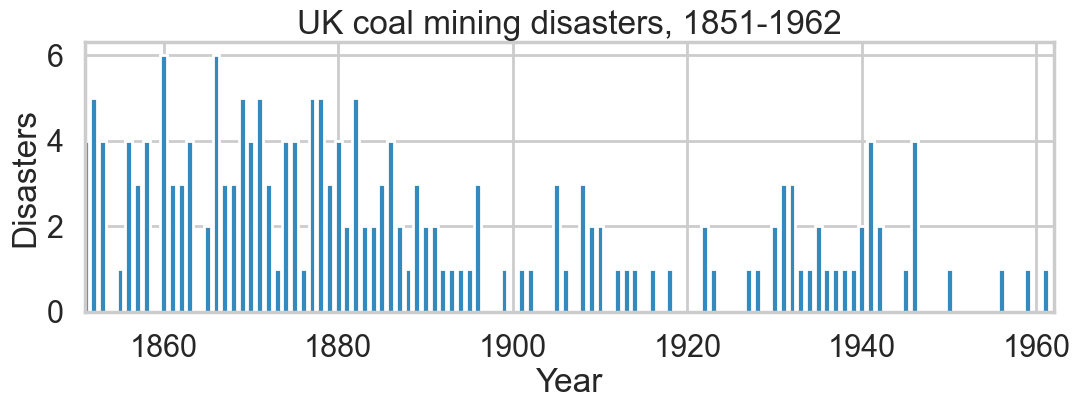

In [3]:
disasters_data = np.array([4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
                         3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
                         2, 2, 3, 4, 2, 1, 3, 2, 2, 1, 1, 1, 1, 3, 0, 0,
                         1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
                         0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
                         3, 3, 1, 1, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
                         0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1])

n_years = len(disasters_data)

plt.figure(figsize=(12.5, 3.5))
plt.bar(np.arange(1851, 1962), disasters_data, color="#348ABD")
plt.xlabel("Year")
plt.ylabel("Disasters")
plt.title("UK coal mining disasters, 1851-1962")
plt.xlim(1851, 1962);

One can see the swtich roughly in the picture above.

### Model

We'll assume a Poisson model for the mine disasters; appropriate because the counts are low.

$$
y \vert \tau, \lambda_1, \lambda_2 \sim Poisson(r_t)\\
r_t = \lambda_1 \,{\rm if}\, t < \tau \,{\rm else}\, \lambda_2 \,{\rm for}\, t \in [t_l, t_h]\\
\tau \sim DiscreteUniform(t_l, t_h)\\
\lambda_1 \sim Exp(a)\\
\lambda_2 \sim Exp(b)\\
$$

The rate parameter varies before and after the switchpoint, which itseld has a discrete-uniform prior on it. Rate parameters get exponential priors.

In [4]:
import pymc as pm
import arviz as az
from pymc.math import switch
with pm.Model() as coaldis1:
    early_mean = pm.Exponential('early_mean', 1)
    late_mean = pm.Exponential('late_mean', 1)
    switchpoint = pm.DiscreteUniform('switchpoint', lower=0, upper=n_years)
    rate = switch(switchpoint >= np.arange(n_years), early_mean, late_mean)
    disasters = pm.Poisson('disasters', mu=rate, observed=disasters_data)


In [5]:
try:
    pm.model_to_graphviz(coaldis1)
except ImportError:
    print("graphviz not available, skipping model visualization")

graphviz not available, skipping model visualization


Let us interrogate our model about the various parts of it. The free random variables are the stochastics we defined. PyMC internally applies transforms (e.g. log for positive-valued parameters) during sampling, which we can inspect via `rvs_to_transforms`.

In [6]:
coaldis1.free_RVs #stochastics

[early_mean, late_mean, switchpoint]

In [7]:
# In pymc v5, transformed variables are accessed via model.rvs_to_transforms
# This shows which RVs have internal transforms (e.g. log for Exponential)
{rv.name: tr.name if tr is not None else "none" for rv, tr in coaldis1.rvs_to_transforms.items()}

{'early_mean': 'log',
 'late_mean': 'log',
 'switchpoint': 'none',
 'disasters': 'none'}

In [8]:
coaldis1.deterministics #deterministics

[]

Labelled variables show up in traces, or for predictives. We also list the "likelihood" stochastics.

In [9]:
# In modern pymc, use model.free_RVs, model.observed_RVs, model.deterministics
{rv.name: rv for rv in coaldis1.free_RVs + coaldis1.observed_RVs + coaldis1.deterministics}

{'early_mean': early_mean,
 'late_mean': late_mean,
 'switchpoint': switchpoint,
 'disasters': disasters}

In [10]:
coaldis1.observed_RVs

[disasters]

The DAG based structure and notation used in pymc3 and similar software makes no distinction between random variables and data. Everything is a node, and some nodes are conditioned upon. This is reminiscent of the likelihood being considered a function of its parameters. But you can consider it as a function of data with fixed parameters and sample from it.

You can sample from the distributions in `pymc3`.

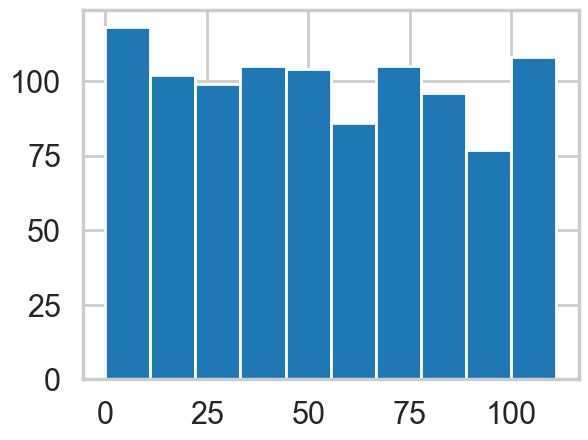

In [11]:
with coaldis1:
    plt.hist(pm.draw(coaldis1['switchpoint'], draws=1000));

In [12]:
# In pymc v5, distribution info is accessed through the model owner graph.
# We can inspect the distribution type (Op) for each RV:
for rv in coaldis1.free_RVs:
    print(f"{rv.name}: {rv.owner.op}")

early_mean: exponential_rv{"()->()"}
late_mean: exponential_rv{"()->()"}
switchpoint: discrete_uniform_rv{"(),()->()"}


In [13]:
# Distribution parameters can be inspected via the RV's owner inputs.
# For switchpoint (DiscreteUniform), the inputs are lower and upper bounds:
for rv in coaldis1.free_RVs:
    print(f"{rv.name}: inputs = {rv.owner.inputs}")

early_mean: inputs = [RNG(<Generator(PCG64) at 0x119D07D80>), Constant(<pytensor.tensor.type_other.NoneTypeT object at 0x10de9cc20>, data=None), Reciprocal.0]
late_mean: inputs = [RNG(<Generator(PCG64) at 0x10D86A420>), Constant(<pytensor.tensor.type_other.NoneTypeT object at 0x10de9cc20>, data=None), Reciprocal.0]
switchpoint: inputs = [RNG(<Generator(PCG64) at 0x11A0A0820>), Constant(<pytensor.tensor.type_other.NoneTypeT object at 0x10de9cc20>, data=None), Floor.0, Floor.0]


In [14]:
ed=pm.Exponential.dist(1)
print(type(ed))
pm.draw(ed, draws=10)

<class 'pytensor.tensor.variable.TensorVariable'>


array([1.60391016, 0.24965977, 1.74990034, 0.22793361, 1.81421517,
       0.06244465, 0.15160018, 1.25886023, 0.52106574, 0.29085251])

In [15]:
type(switchpoint), type(early_mean)

(pytensor.tensor.variable.TensorVariable,
 pytensor.tensor.variable.TensorVariable)

Most importantly, anything distribution-like must have a `logp` method. This is what enables calculating the acceptance ratio for sampling:

In [16]:
# In pymc v5, use model.point_logps() to evaluate the log-probability
# at the model's initial point, or compile_logp() for a callable function.
coaldis1.point_logps()

{'early_mean': np.float64(-1.0),
 'late_mean': np.float64(-1.0),
 'switchpoint': np.float32(-4.72),
 'disasters': np.float64(-225.81)}

Ok, enough talk, lets sample:

In [17]:
with coaldis1:
    #stepper=pm.Metropolis()
    #idata = pm.sample(40000, step=stepper)
    idata = pm.sample(40000)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>NUTS: [early_mean, late_mean]


>Metropolis: [switchpoint]


/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 40_000 draw iterations (4_000 + 160_000 draws total) took 11 seconds.


In [18]:
az.summary(idata.sel(draw=slice(4000, None, 5)))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
switchpoint,39.005,2.466,34.000,43.000,0.021,0.016,14204.0,16147.0,1.0
early_mean,3.065,0.284,2.526,3.594,0.002,0.001,26733.0,27913.0,1.0
late_mean,0.936,0.118,0.714,1.153,0.001,0.001,25938.0,27948.0,1.0


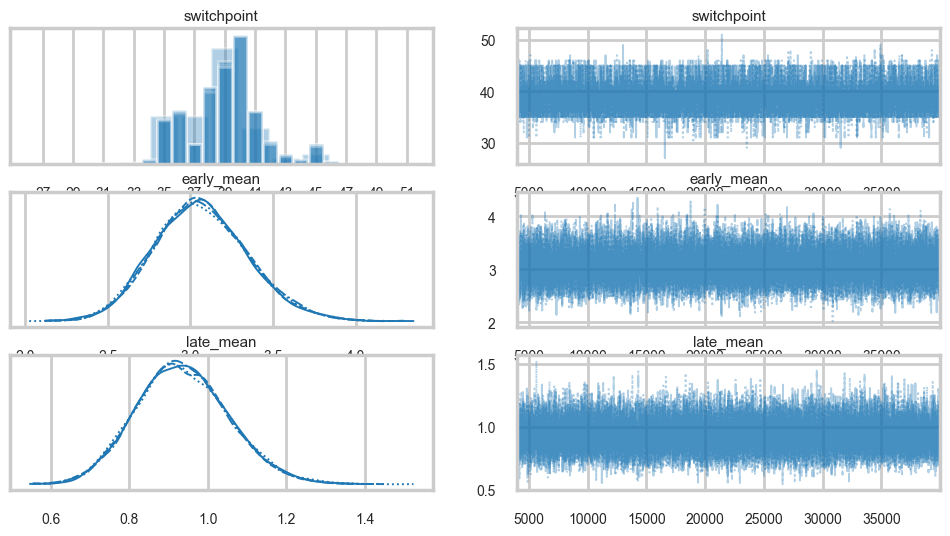

In [19]:
idata_burned = idata.sel(draw=slice(4000, None, 5))
az.plot_trace(idata_burned);

A forestplot gives us 95% credible intervals...

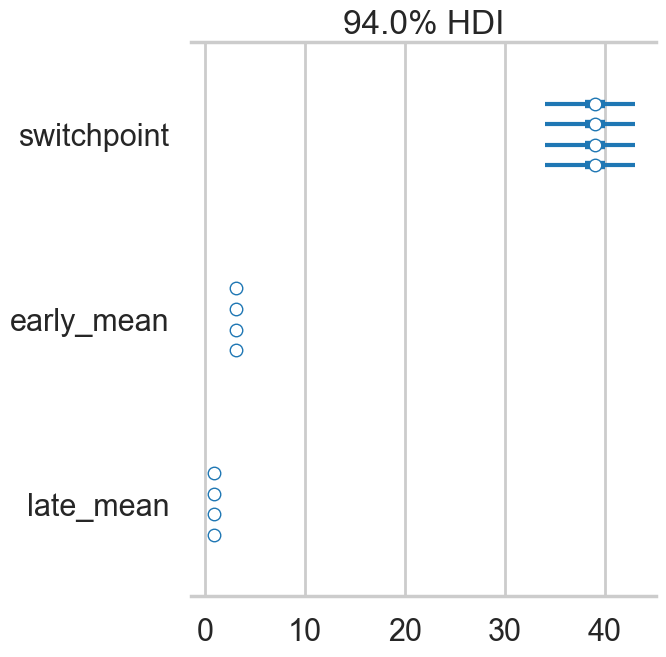

In [20]:
az.plot_forest(idata_burned);

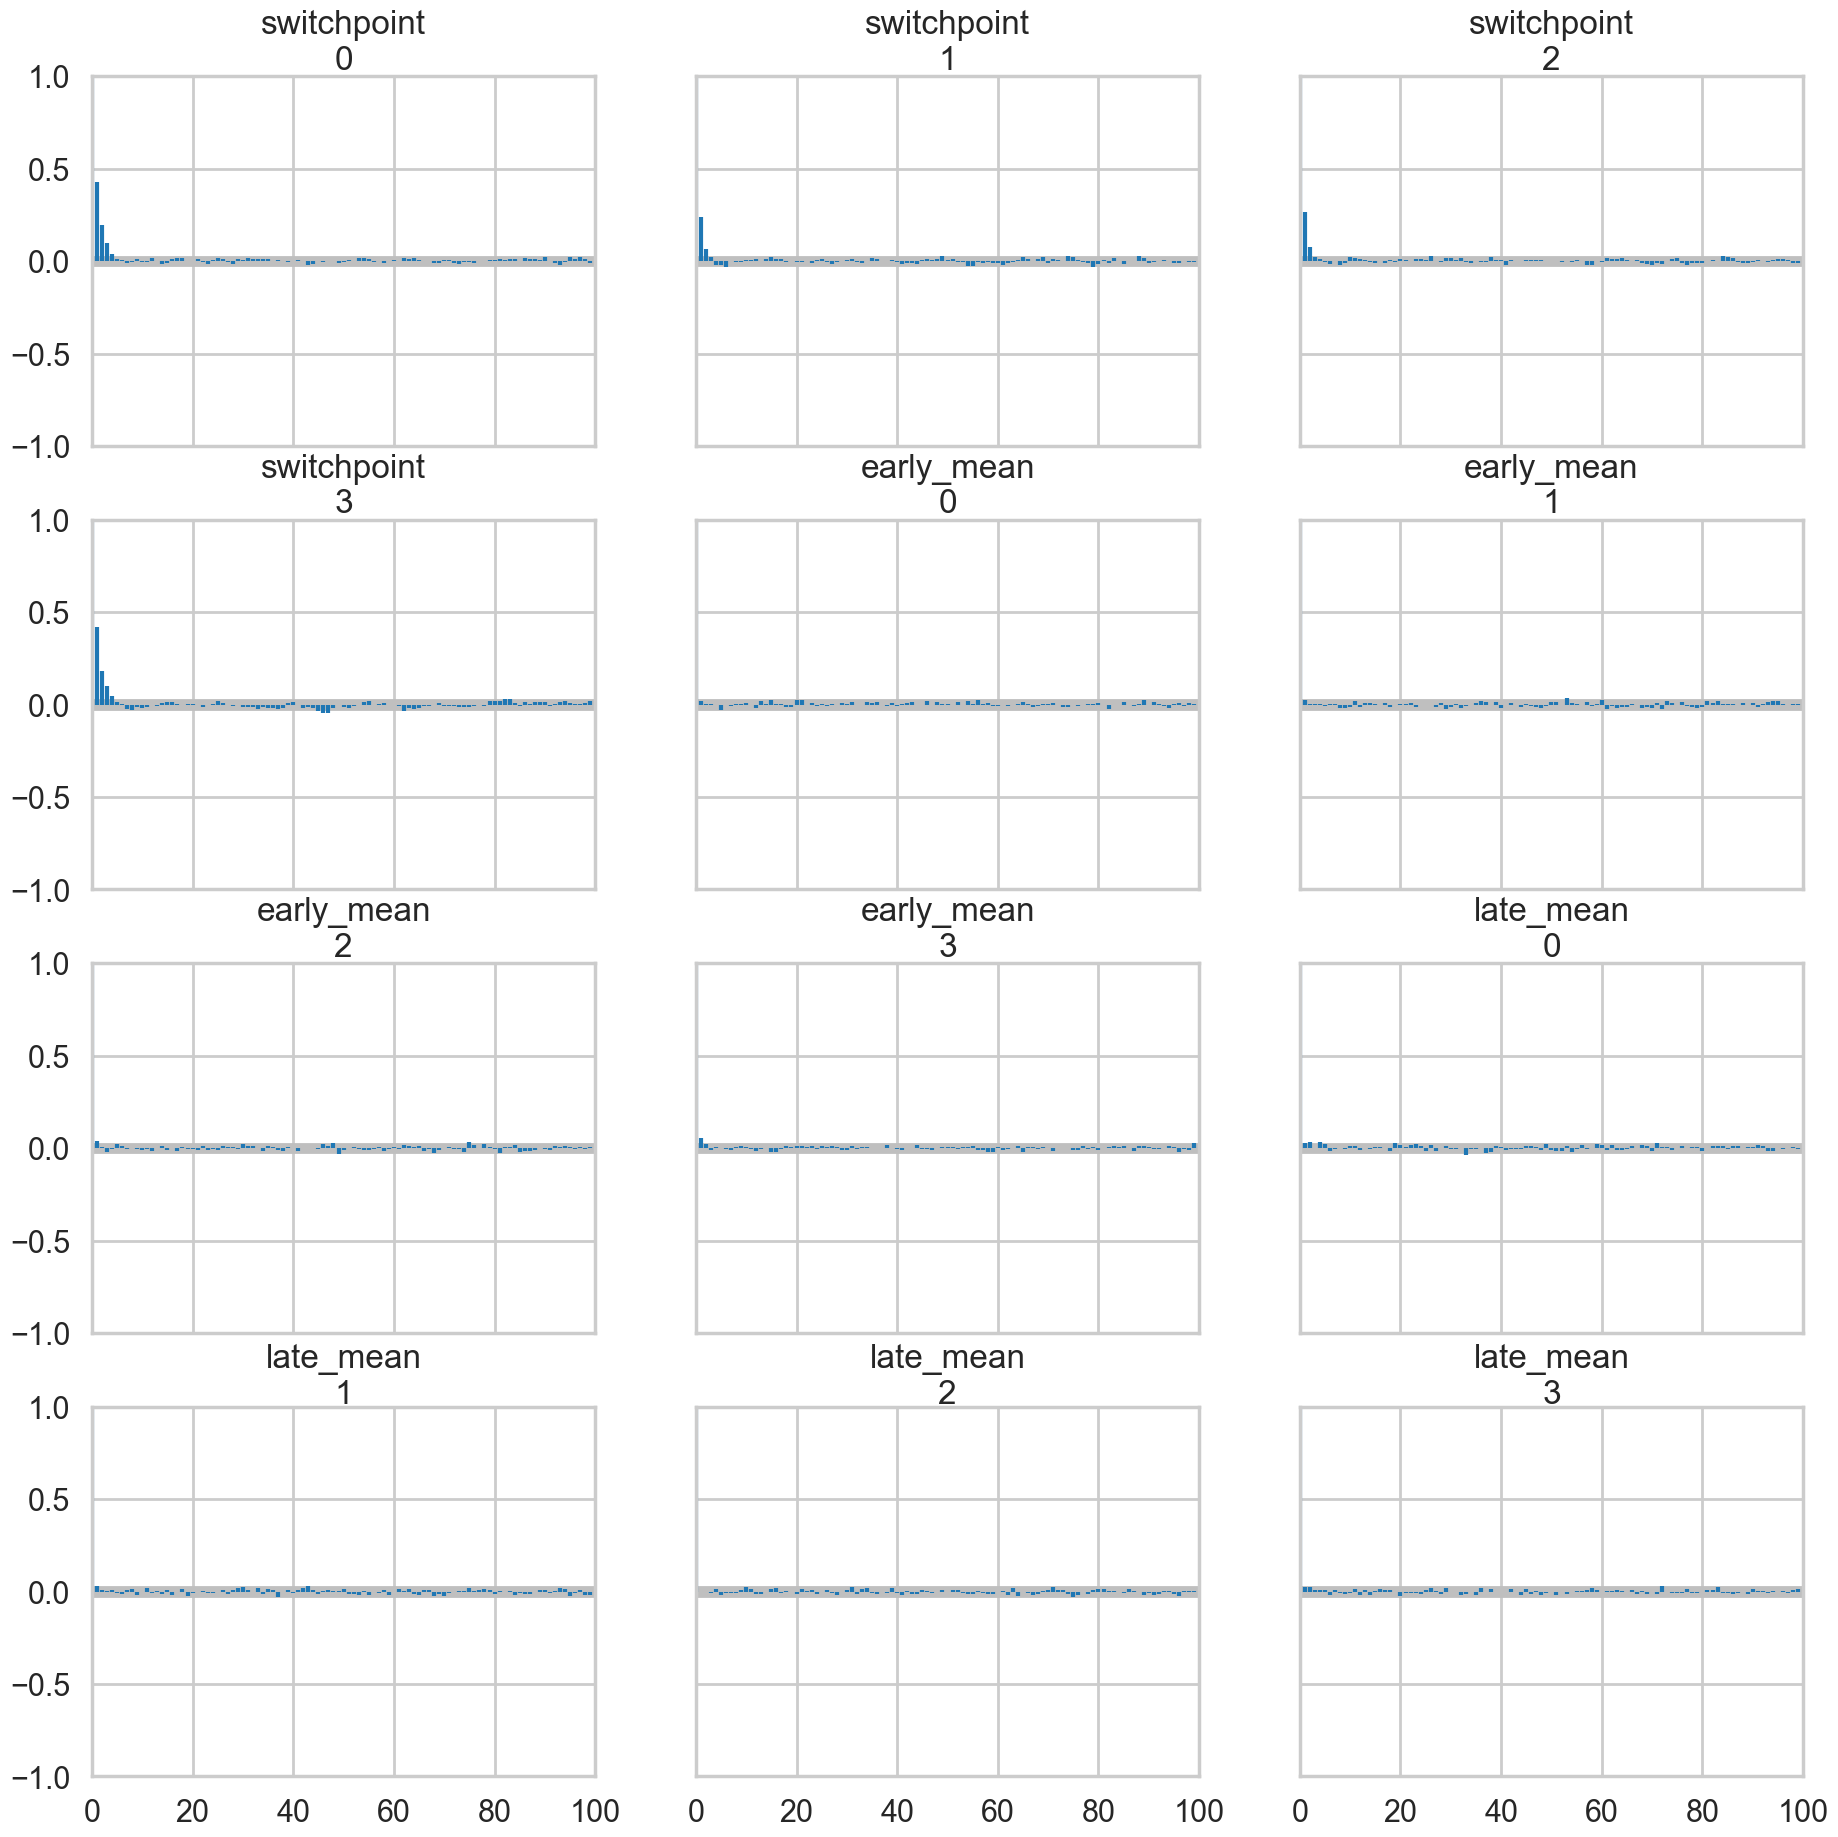

In [21]:
az.plot_autocorr(idata_burned);

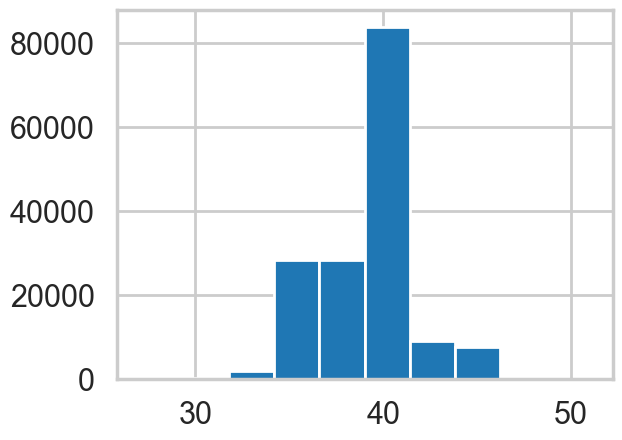

In [22]:
plt.hist(idata.posterior['switchpoint'].values.flatten());

In [23]:
idata_burned.posterior.to_dataframe().corr()

,switchpoint,early_mean,late_mean
switchpoint,1.000000,-0.270741,-0.231414
early_mean,-0.270741,1.000000,0.062379
late_mean,-0.231414,0.062379,1.000000


## Imputation

Imputation of missing data vaues has a very nice process in Bayesian stats: just sample them from the posterior predictive. There is a very nice process to do this built into pync3..you could abuse this to calculate predictives at arbitrary points. (There is a better way for that, though, using Theano shared variables, so you might want to restrict this process to the situation where you need to impute a few values only).

Below we use -999 to handle mising data:

In [24]:
disasters_missing = np.array([ 4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
2, 2, 3, 4, 2, 1, 3, -999, 2, 1, 1, 1, 1, 3, 0, 0,
1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
3, 3, 1, -999, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1])

In [25]:
disasters_masked = np.ma.masked_values(disasters_missing, value=-999)
disasters_masked

masked_array(data=[4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6, 3, 3,
                   5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5, 2, 2, 3, 4,
                   2, 1, 3, --, 2, 1, 1, 1, 1, 3, 0, 0, 1, 0, 1, 1, 0, 0,
                   3, 1, 0, 3, 2, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 2,
                   1, 0, 0, 0, 1, 1, 0, 2, 3, 3, 1, --, 2, 1, 1, 1, 1, 2,
                   4, 2, 0, 0, 1, 4, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
                   1, 0, 1],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False,  True,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
      

In [26]:
with pm.Model() as missing_data_model:
    switchpoint = pm.DiscreteUniform('switchpoint', lower=0, upper=len(disasters_masked))
    early_mean = pm.Exponential('early_mean', lam=1.)
    late_mean = pm.Exponential('late_mean', lam=1.)
    idx = np.arange(len(disasters_masked))
    rate = pm.Deterministic('rate', switch(switchpoint >= idx, early_mean, late_mean))
    disasters = pm.Poisson('disasters', rate, observed=disasters_masked)

/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in disasters contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


In [27]:
try:
    pm.model_to_graphviz(missing_data_model)
except ImportError:
    print("graphviz not available, skipping model visualization")

graphviz not available, skipping model visualization


By supplying a masked array to the likelihood part of our model, we ensure that the masked data points show up in our traces:

In [28]:
with missing_data_model:
    stepper=pm.Metropolis()
    idata_missing = pm.sample(40000, step=stepper)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [switchpoint]


>Metropolis: [early_mean]


>Metropolis: [late_mean]


>Metropolis: [disasters_unobserved]


/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 40_000 draw iterations (4_000 + 160_000 draws total) took 13 seconds.


In [29]:
idata_m_burned = idata_missing.sel(draw=slice(4000, None, 5))

In [30]:
az.summary(idata_m_burned)

/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
switchpoint,38.801,2.445,35.000,43.000,0.025,0.016,9899.0,14328.0,1.0
disasters_unobserved[0],2.146,1.798,0.000,5.000,0.017,0.010,10814.0,14542.0,1.0
disasters_unobserved[1],0.926,0.972,0.000,3.000,0.007,0.006,20599.0,21554.0,1.0
early_mean,3.086,0.285,2.572,3.636,0.002,0.002,15500.0,17353.0,1.0
late_mean,0.932,0.117,0.719,1.155,0.001,0.001,15902.0,17191.0,1.0
...,...,...,...,...,...,...,...,...,...
disasters[106],0.000,0.000,0.000,0.000,0.000,NaN,28800.0,28800.0,NaN
disasters[107],0.000,0.000,0.000,0.000,0.000,NaN,28800.0,28800.0,NaN
disasters[108],1.000,0.000,1.000,1.000,0.000,NaN,28800.0,28800.0,NaN
disasters[109],0.000,0.000,0.000,0.000,0.000,NaN,28800.0,28800.0,NaN


In [31]:
missing_data_model.free_RVs

[switchpoint, early_mean, late_mean, disasters_unobserved]

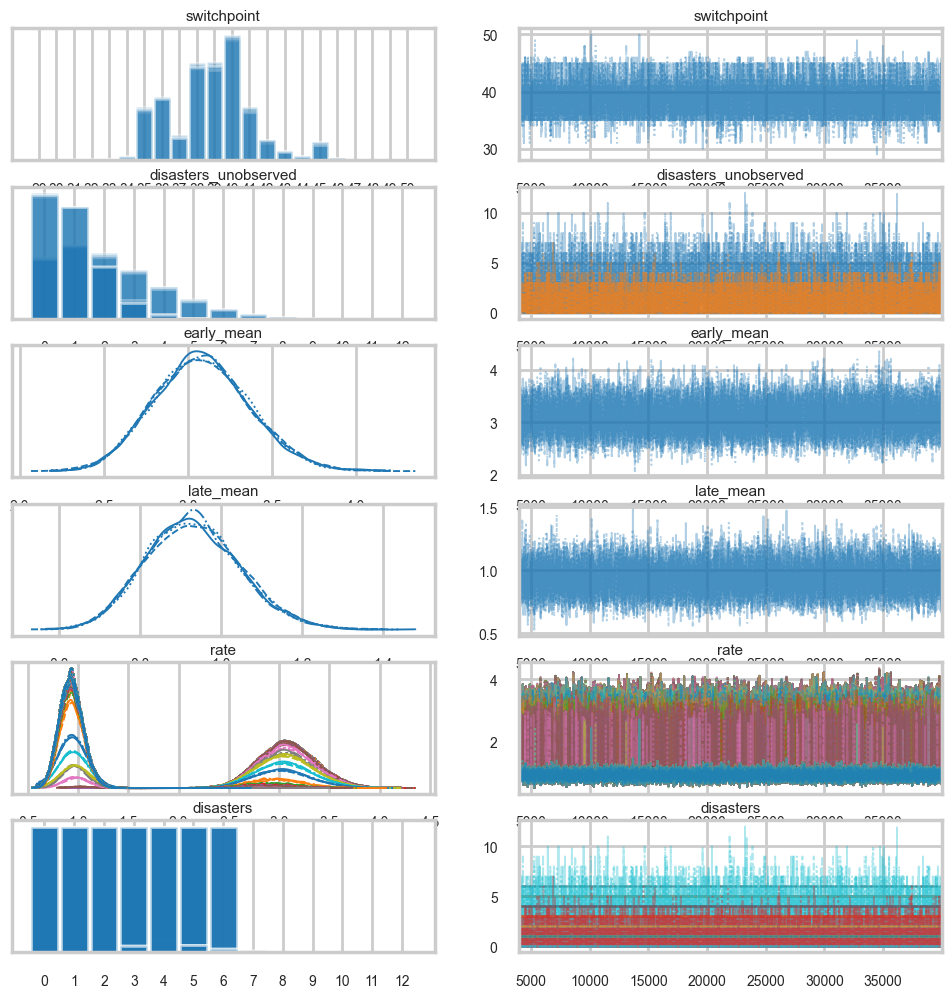

In [32]:
az.plot_trace(idata_m_burned);

## Convergence of our model

Going back to the original model...

### Histograms every m samples

As a visual check, we plot histograms or kdeplots every 500 samples and check that they look identical.

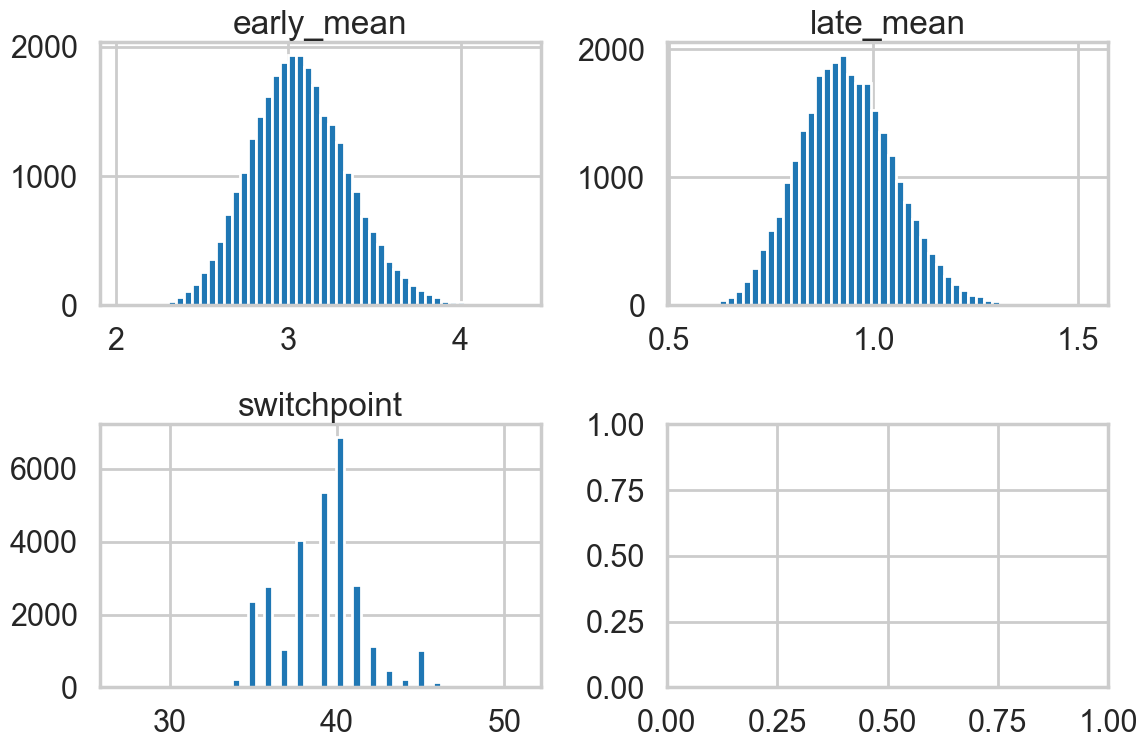

In [33]:
import matplotlib.pyplot as plt

emtrace = idata_burned.posterior['early_mean'].values.flatten()
lmtrace = idata_burned.posterior['late_mean'].values.flatten()
smtrace = idata_burned.posterior['switchpoint'].values.flatten()

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes[0][0].hist(emtrace, bins=50)
axes[0][0].set_title("early_mean")
axes[0][1].hist(lmtrace, bins=50)
axes[0][1].set_title("late_mean")
axes[1][0].hist(smtrace, bins=50)
axes[1][0].set_title("switchpoint")
plt.tight_layout()

### Gewecke test

The gewecke test tests that the difference of means of chain-parts written as a Z-score oscilates between 1 and -1

$$\vert \mu_{\theta_1}  - \mu_{\theta_2}  \vert < 2 \sigma_{\theta_1 - \theta_2} $$



In [34]:
# Geweke diagnostic has been removed from modern pymc/arviz.
# Using az.rhat() for convergence assessment instead.
print('Geweke diagnostic deprecated; see Rhat diagnostics below.')

Geweke diagnostic deprecated; see Rhat diagnostics below.


In [35]:
# z-score output omitted (Geweke diagnostic deprecated)

Here is a plot for `early_mean`. You sould really be plotting all of these...

In [36]:
# Geweke diagnostic is deprecated in modern pymc.
# See Rhat diagnostics below for convergence assessment.


In [37]:
# Geweke z-score plot omitted (diagnostic deprecated).
# Use az.plot_trace() and az.rhat() for convergence assessment.


### Gelman-Rubin

For this test, which calculates 

$$\hat{R} = \sqrt{\frac{\hat{Var}(\theta)}{w}}$$

we need more than 1-chain. This is done through `njobs=4` (the defaukt is 2 and reported in `pm.summary`). See the trace below:

In [38]:
with coaldis1:
    stepper=pm.Metropolis()
    idata2 = pm.sample(40000, step=stepper, cores=4)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [early_mean]


>Metropolis: [late_mean]


>Metropolis: [switchpoint]


/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 40_000 draw iterations (4_000 + 160_000 draws total) took 9 seconds.


In [39]:
idata2

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [40]:
idata2_cut = idata2.sel(draw=slice(4000, None, 5))

In [41]:
# gelman_rubin is now az.rhat()

az.rhat(idata2_cut)

<xarray.Dataset> Size: 24B
Dimensions:      ()
Data variables:
    switchpoint  float64 8B 1.0
    early_mean   float64 8B 1.0
    late_mean    float64 8B 1.0
Attributes:
    created_at:                 2026-03-11T00:48:28.499604+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              8.721096992492676
    tuning_steps:               1000

For the best results, each chain should be initialized to highly dispersed starting values for each stochastic node.

A foresplot will show you the credible-interval consistency of our chains..

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

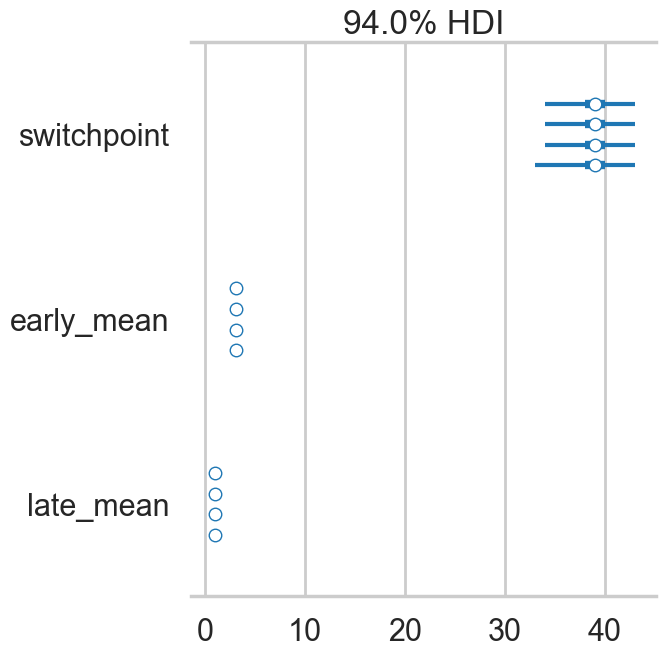

In [42]:
# forestplot is now az.plot_forest()

az.plot_forest(idata2_cut)

### Autocorrelation

This can be probed by plotting the correlation plot and effective sample size

In [43]:
# effective_n is now az.ess()

az.ess(idata2_cut)

<xarray.Dataset> Size: 24B
Dimensions:      ()
Data variables:
    switchpoint  float64 8B 1.523e+04
    early_mean   float64 8B 1.63e+04
    late_mean    float64 8B 1.623e+04
Attributes:
    created_at:                 2026-03-11T00:48:28.499604+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              8.721096992492676
    tuning_steps:               1000

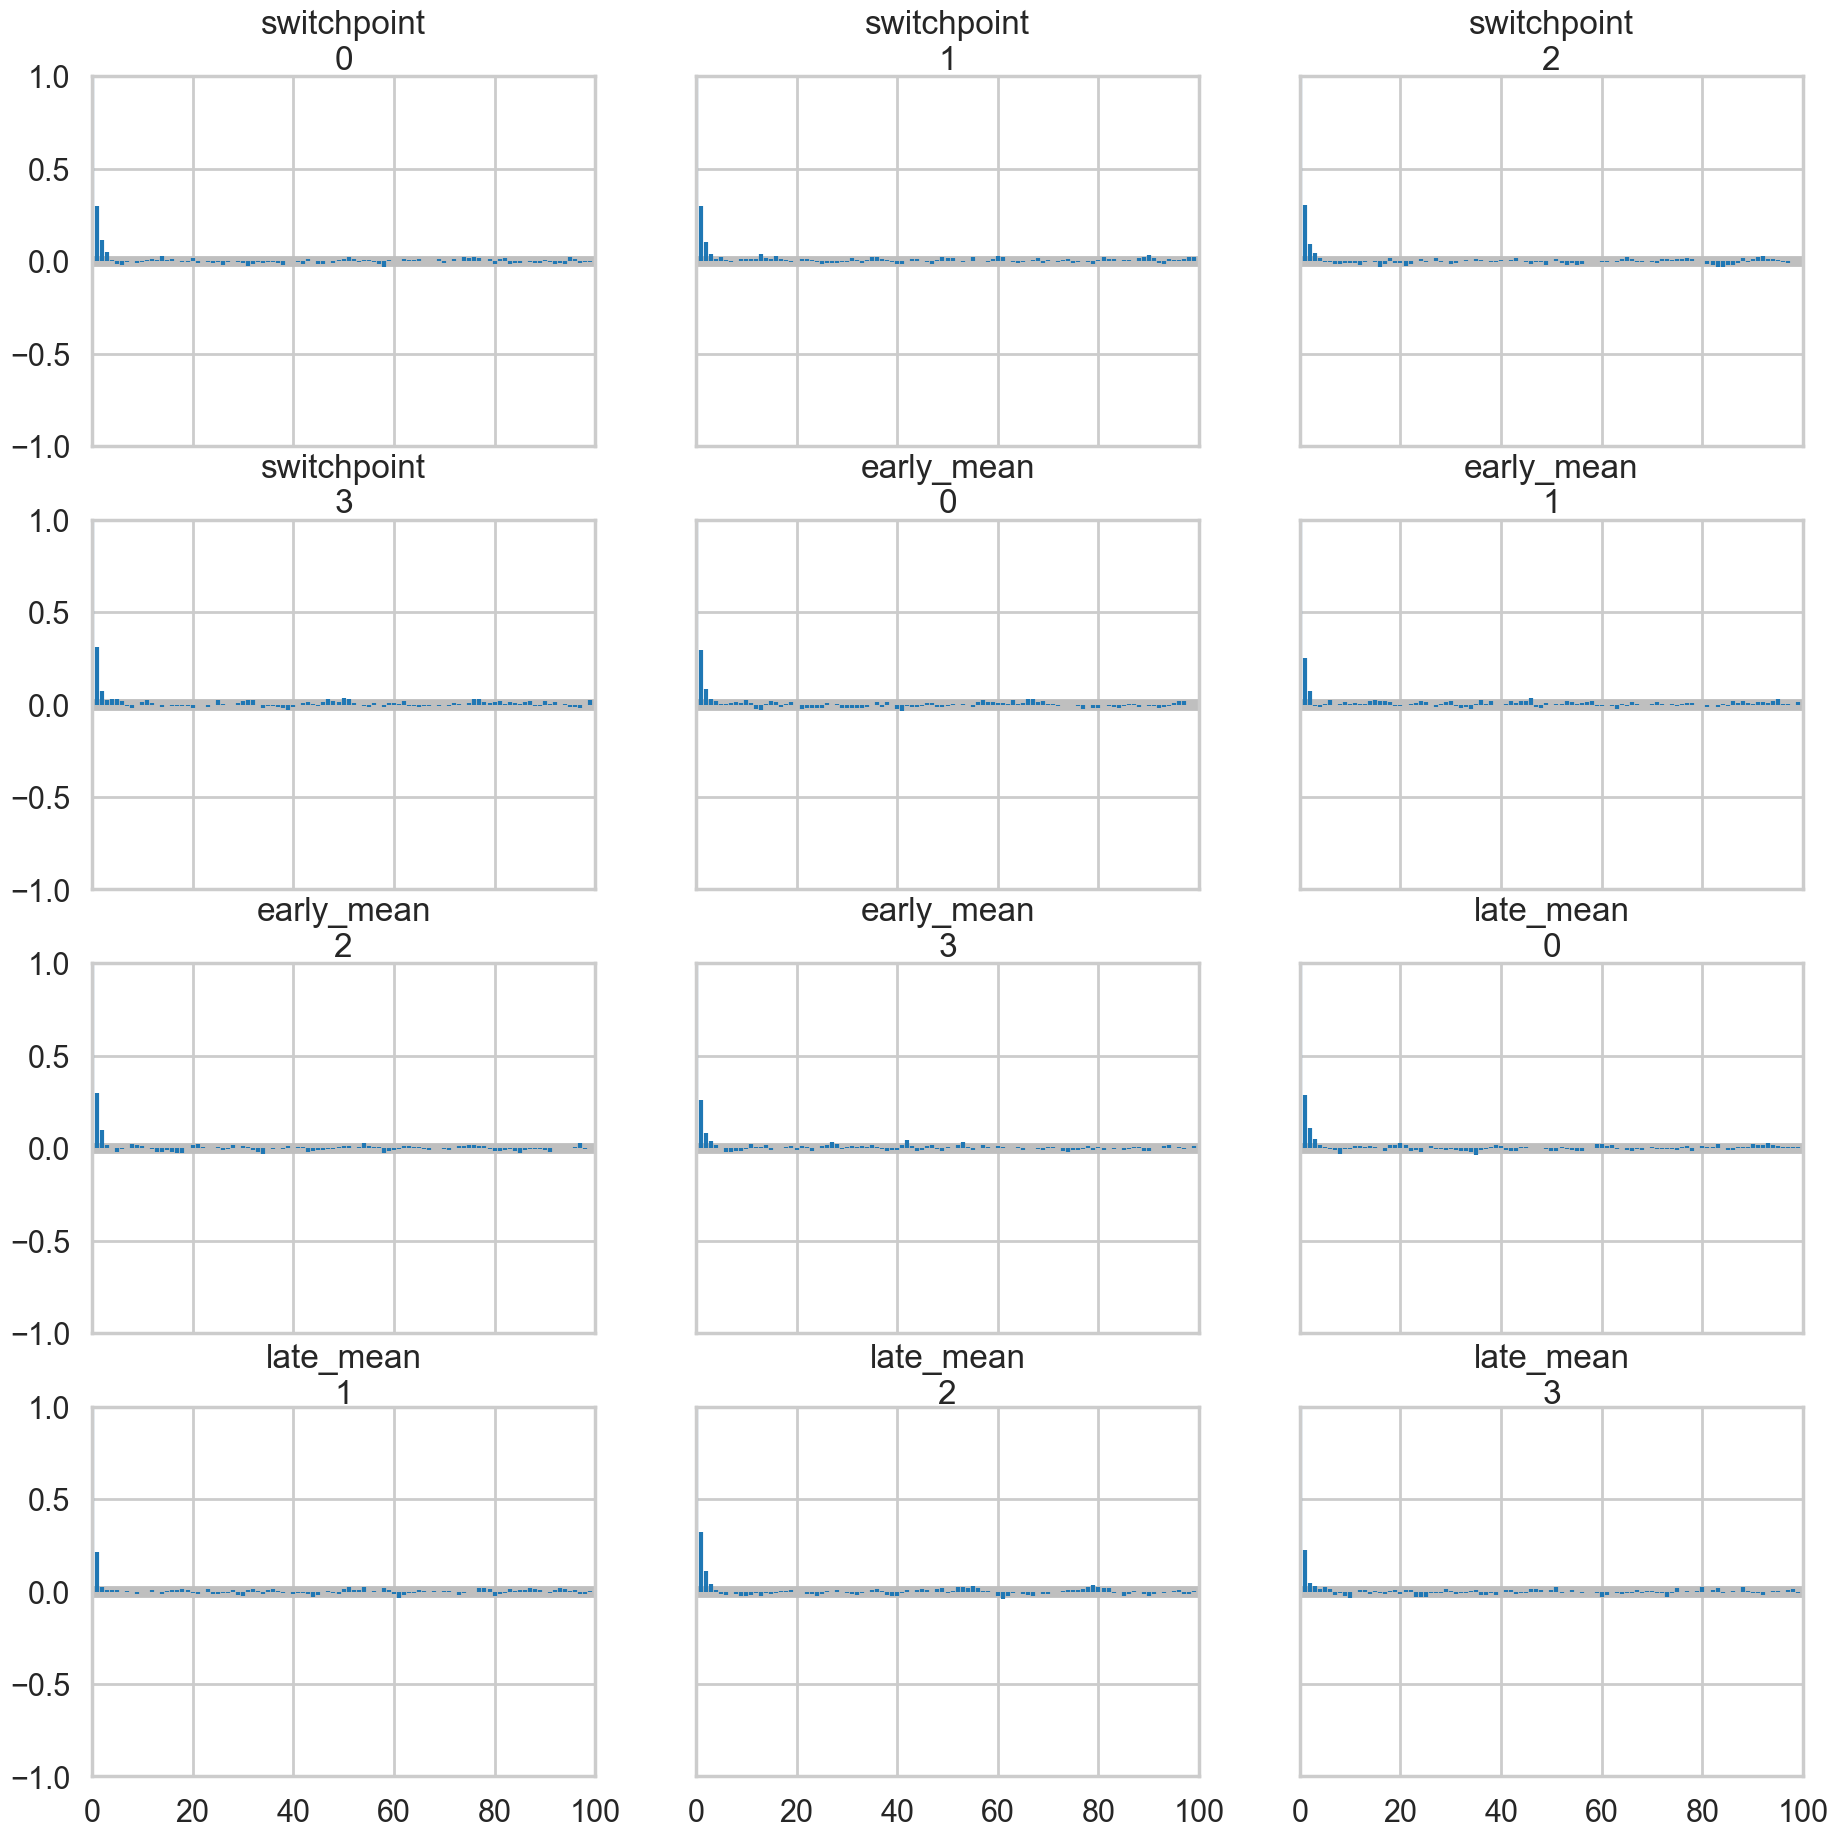

In [44]:
az.plot_autocorr(idata2_cut);

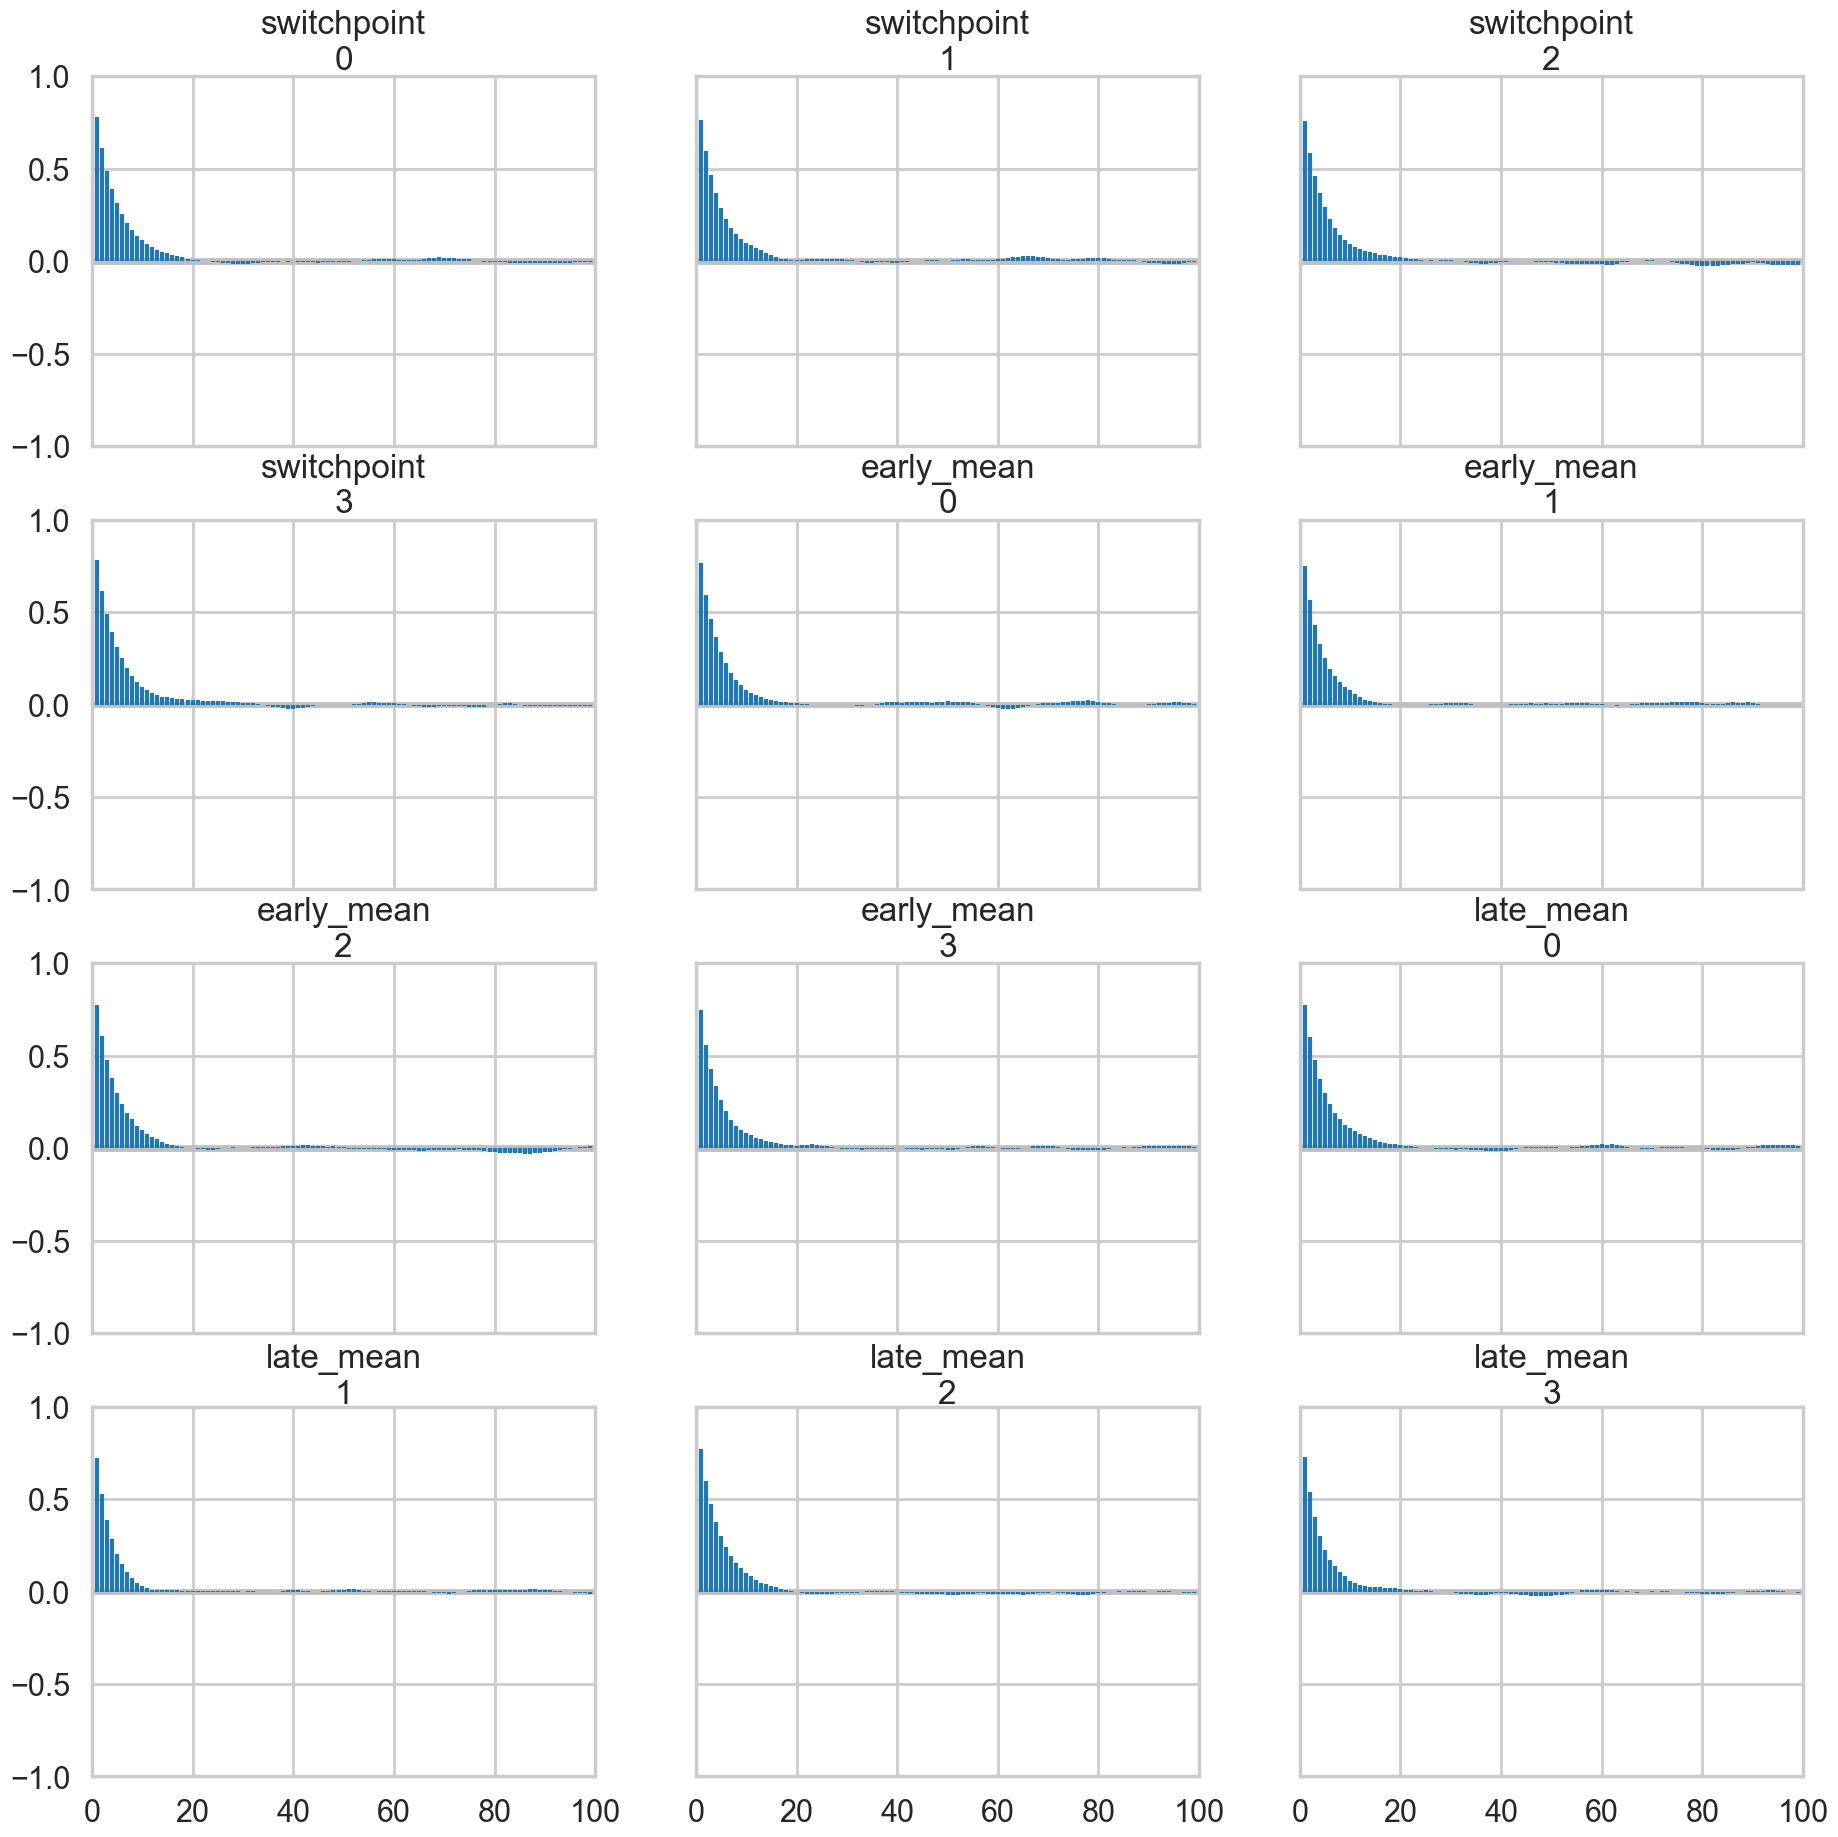

In [45]:
az.plot_autocorr(idata2);

## Posterior predictive checks

Finally let us peek into posterior predictive checks: something we'll talk more about soon.

In [46]:
with coaldis1:
    ppc = pm.sample_posterior_predictive(idata_burned)

Sampling: [disasters]


/Users/rahul/Library/Caches/uv/archive-v0/l4LpQWbyS9KtMNNEoE2Lo/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [47]:
ppc.posterior_predictive['disasters'].shape

(4, 7200, 111)

This gives us 200 samples at each of the 111 diasters we have data on.

We plot the first 4 posteriors against actual data for consistency...

(4,)
4
5
4
0


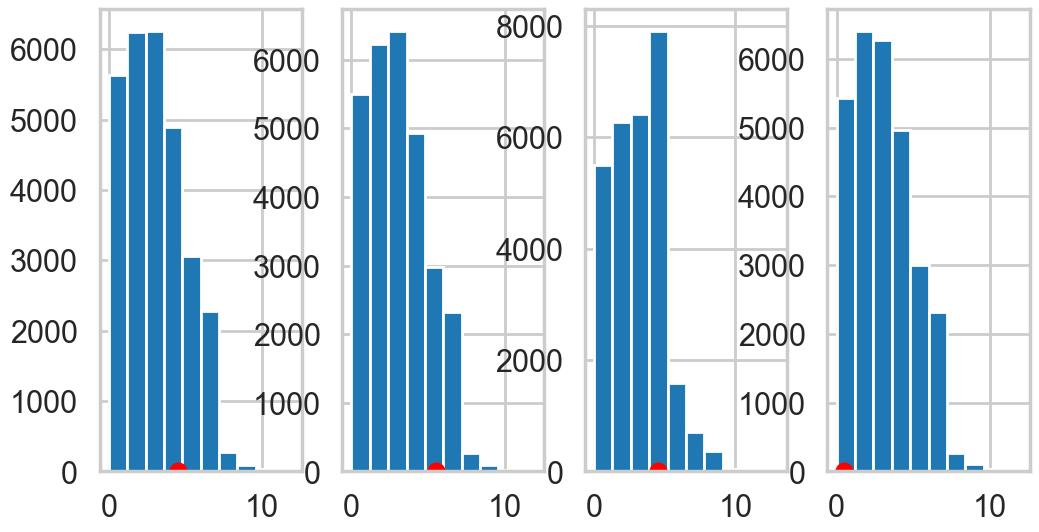

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
print(axes.shape)
ppc_disasters = ppc.posterior_predictive['disasters'].values.reshape(-1, ppc.posterior_predictive['disasters'].shape[-1])
for obs, s, ax in zip(disasters_data, ppc_disasters.T, axes):
    print(obs)
    ax.hist(s, bins=10)
    ax.plot(obs+0.5, 1, 'ro')